# Sales Analysis

Source: sales_clean.parquet, customers_clean.parquet, products_clean.parquet

Covers: revenue trends, YoY growth, online vs in-store, geography, top products

### Imports

In [1]:
import pandas as pd
from src.analysis import sales
from src.viz import base

### Load data

In [2]:
df       = pd.read_parquet("../data/processed/sales_clean.parquet")
customers = pd.read_parquet("../data/processed/customers_clean.parquet")
products  = pd.read_parquet("../data/processed/products_clean.parquet")

# targeted joins — only columns needed for this analysis
df = df.merge(customers[["CustomerKey", "Country", "Continent"]], on="CustomerKey", how="left")
df = df.merge(products[["ProductKey", "Product Name", "Category"]], on="ProductKey", how="left")

print(df.shape)
df.head()

(62884, 23)


,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,Is Online,...,Order Date Year,Order Date Month,Order Date Quarter,Unit Price USD,Exchange,Revenue USD,Country,Continent,Product Name,Category
0,366000,1,2016-01-01,NaT,265598,10,1304,1,CAD,False,...,2016,1,1,68.00,1.3884,48.98,Canada,North America,Contoso Lens Adapter M450 White,Cameras and camcorders
1,366001,1,2016-01-01,2016-01-13,1269051,0,1048,2,USD,True,...,2016,1,1,427.00,1.0000,854.00,United States,North America,A. Datum SLR Camera X136 Silver,Cameras and camcorders
2,366001,2,2016-01-01,2016-01-13,1269051,0,2007,1,USD,True,...,2016,1,1,665.94,1.0000,665.94,United States,North America,Fabrikam Microwave 1.5CuFt X1100 Black,Home Appliances
3,366002,1,2016-01-01,2016-01-12,266019,0,1106,7,CAD,True,...,2016,1,1,322.00,1.3884,1623.45,Canada,North America,Contoso SLR Camera M146 Orange,Cameras and camcorders
4,366002,2,2016-01-01,2016-01-12,266019,0,373,1,CAD,True,...,2016,1,1,326.00,1.3884,234.80,Canada,North America,Adventure Works Laptop8.9 E0890 White,Computers


## Monthly Revenue Trend

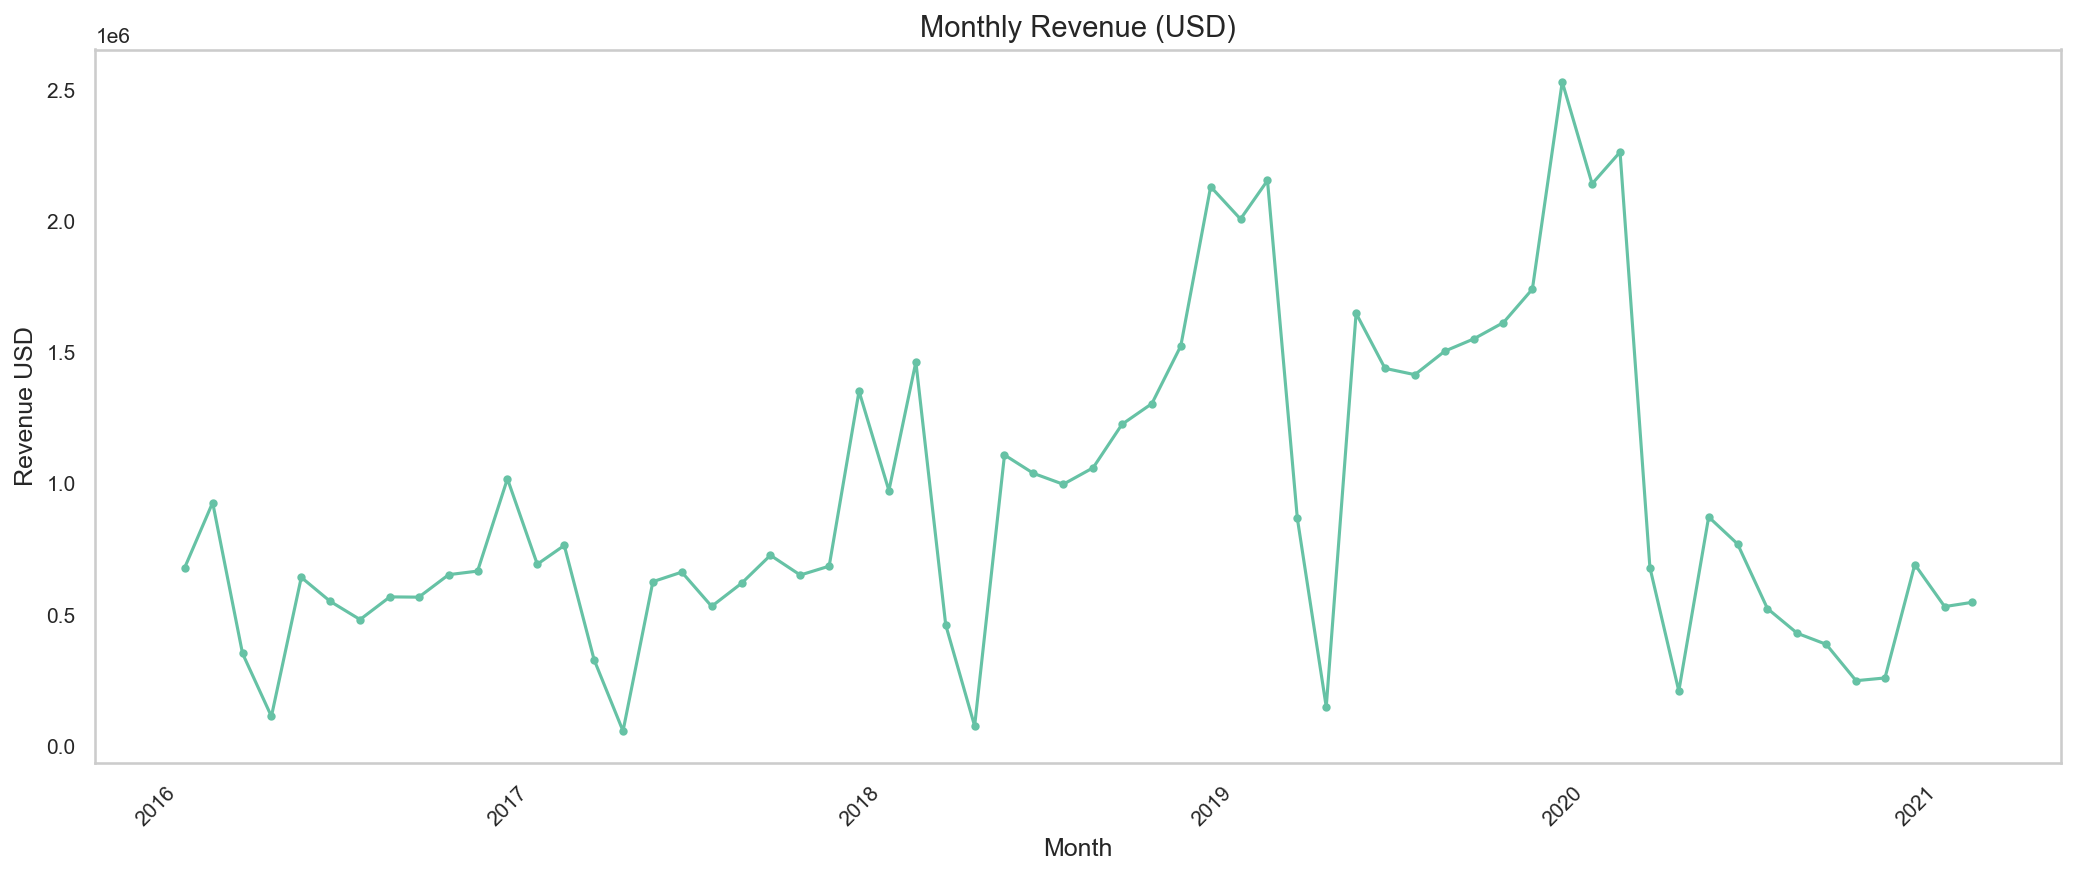

In [3]:
monthly = sales.revenue_by_month(df)
fig, ax = base.line(
    monthly,
    x="Order Date",
    y="Revenue USD",
    title="Monthly Revenue (USD)",
    xlabel="Month",
    ylabel="Revenue USD",
    filename="sales_monthly_revenue.png"
)

display(fig)

## Annual Revenue

,Order Date Year,Revenue USD
0,2016,7235759.76
1,2017,7712690.35
2,2018,13377811.12
3,2019,18632867.34
4,2020,9491415.70
5,2021,1080794.19


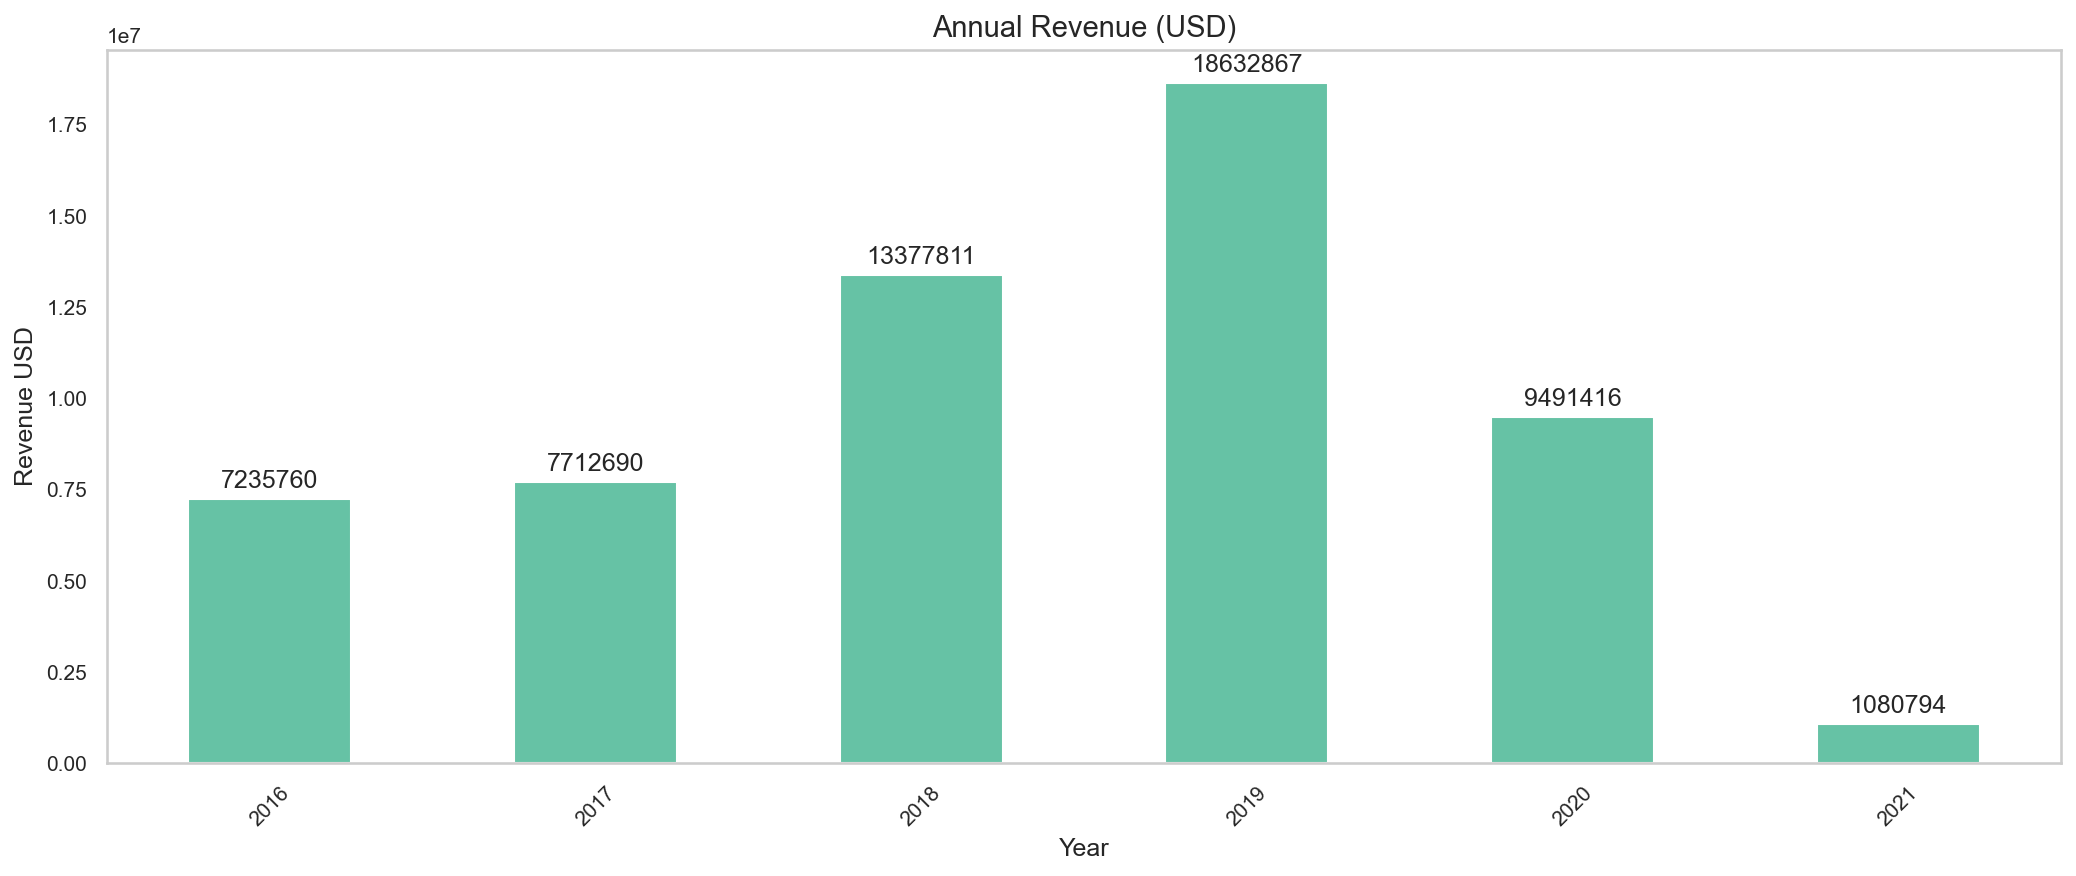

In [4]:
annual = sales.revenue_by_year(df)
display(annual)
fig, ax = base.bar(
    annual.set_index("Order Date Year")["Revenue USD"],
    title="Annual Revenue (USD)",
    xlabel="Year",
    ylabel="Revenue USD",
    filename="sales_annual_revenue.png"
)

display(fig)

## Year over Year Growth

,Order Date Year,Revenue USD,yoy_growth_pct
0,2016,7235759.76,NaN
1,2017,7712690.35,6.59
2,2018,13377811.12,73.45
3,2019,18632867.34,39.28
4,2020,9491415.70,-49.06
5,2021,1080794.19,-88.61


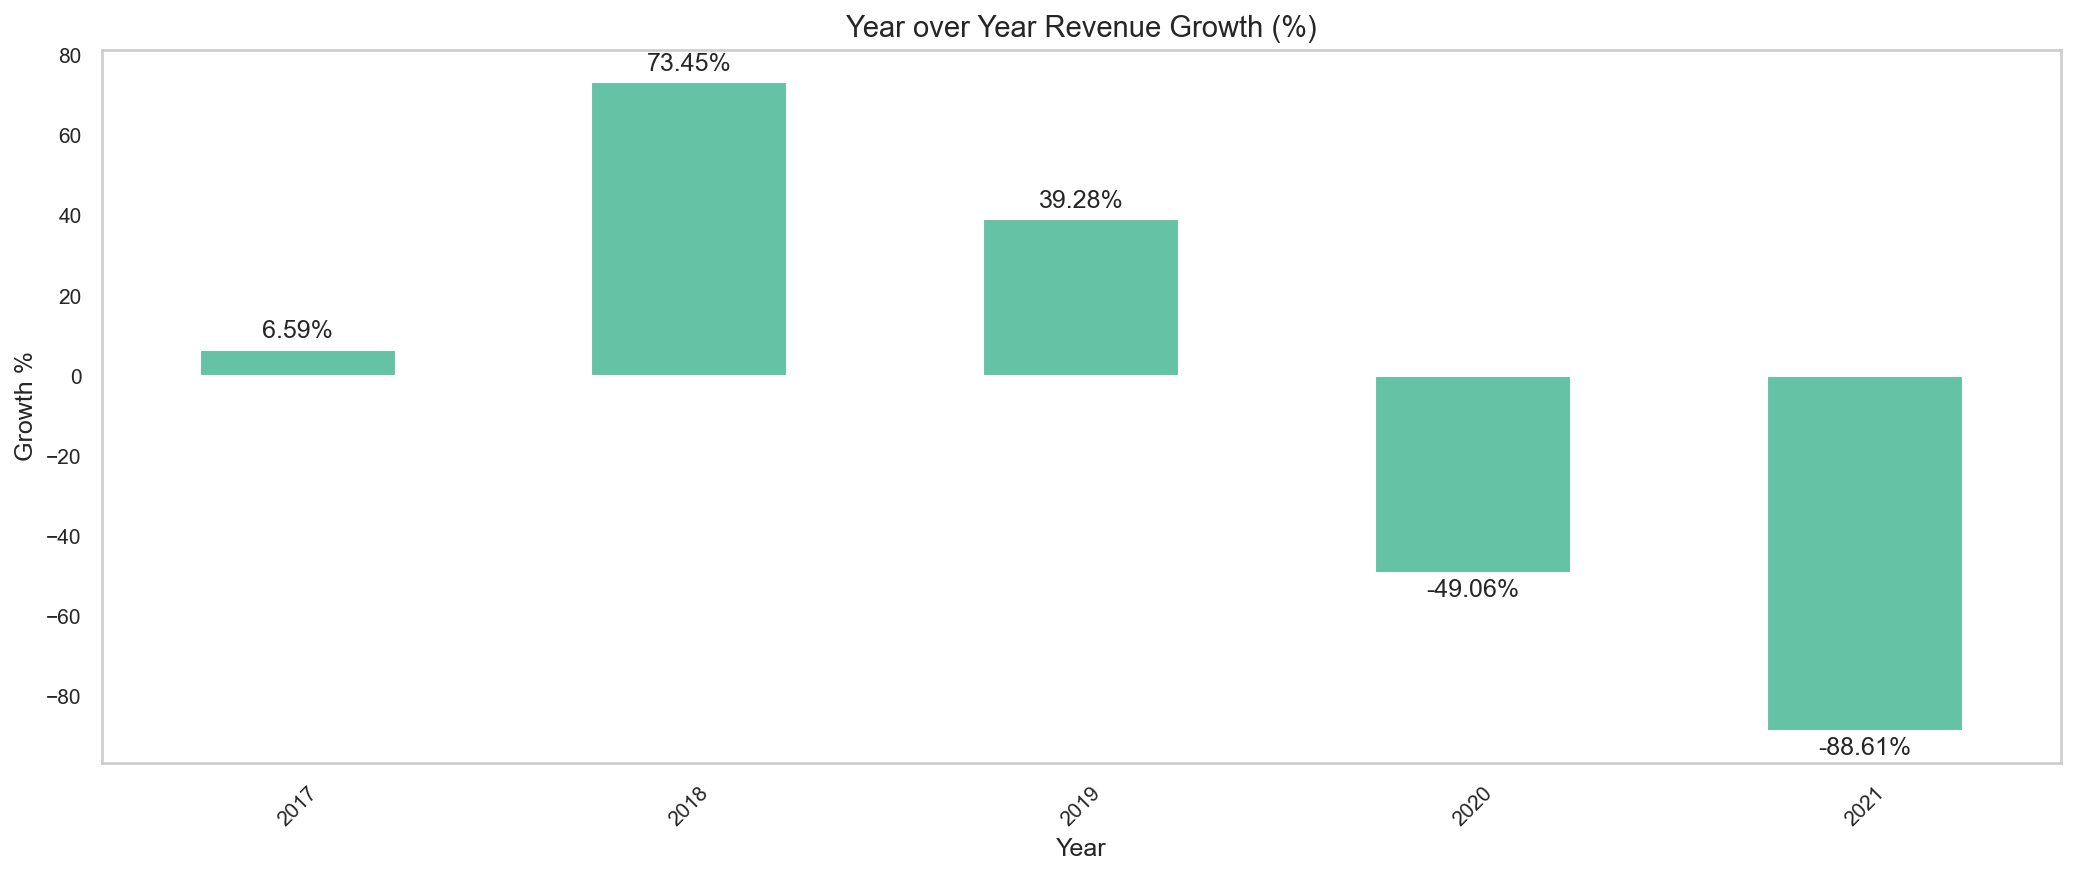

In [5]:
yoy = sales.yoy_revenue_growth(df)
display(yoy)
fig, ax = base.bar(
    yoy.set_index("Order Date Year")["yoy_growth_pct"].dropna(),
    title="Year over Year Revenue Growth (%)",
    xlabel="Year",
    ylabel="Growth %",
    is_pct=True,
    filename="sales_yoy_growth.png"
)

display(fig)

## Online vs In-Store

,Channel,orders,Revenue USD
0,In-Store,49719,45864676.13
1,Online,13165,11666662.33


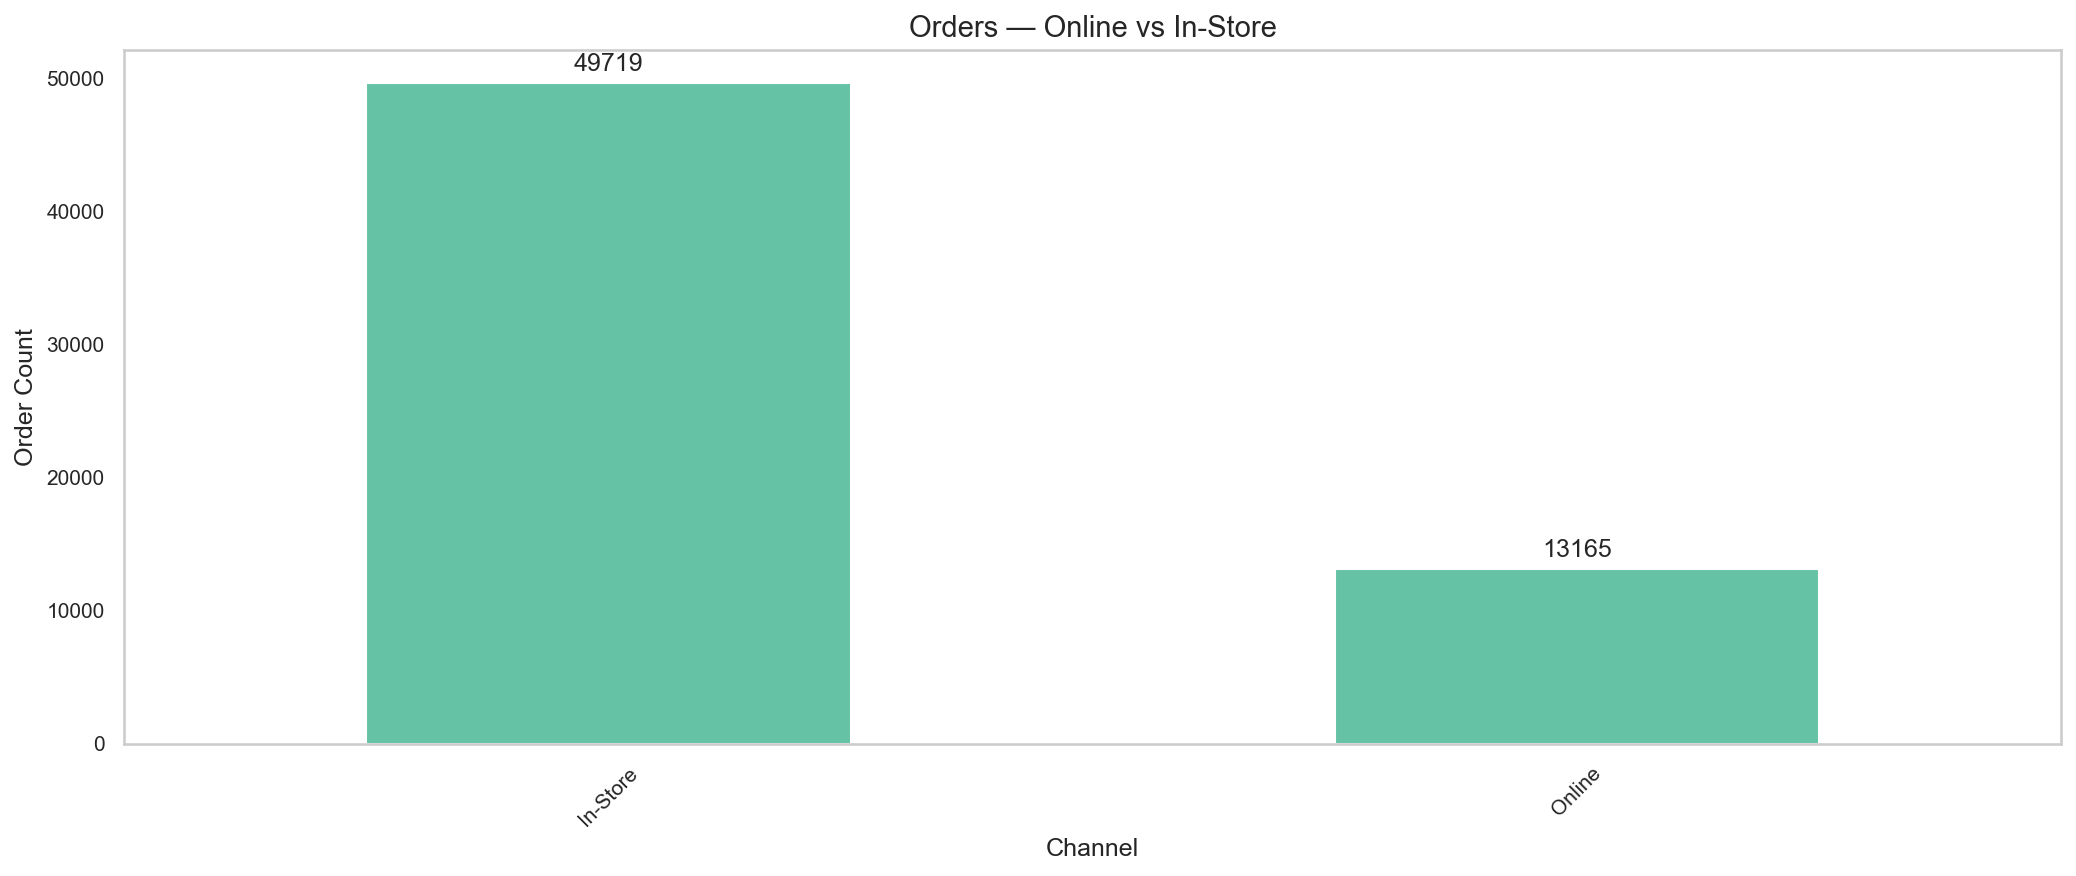

In [6]:
channel = sales.online_vs_instore(df)
display(channel)
fig, ax = base.bar(
    channel.set_index("Channel")["orders"],
    title="Orders — Online vs In-Store",
    xlabel="Channel",
    ylabel="Order Count",
    filename="sales_channel_orders.png"
)

display(fig)

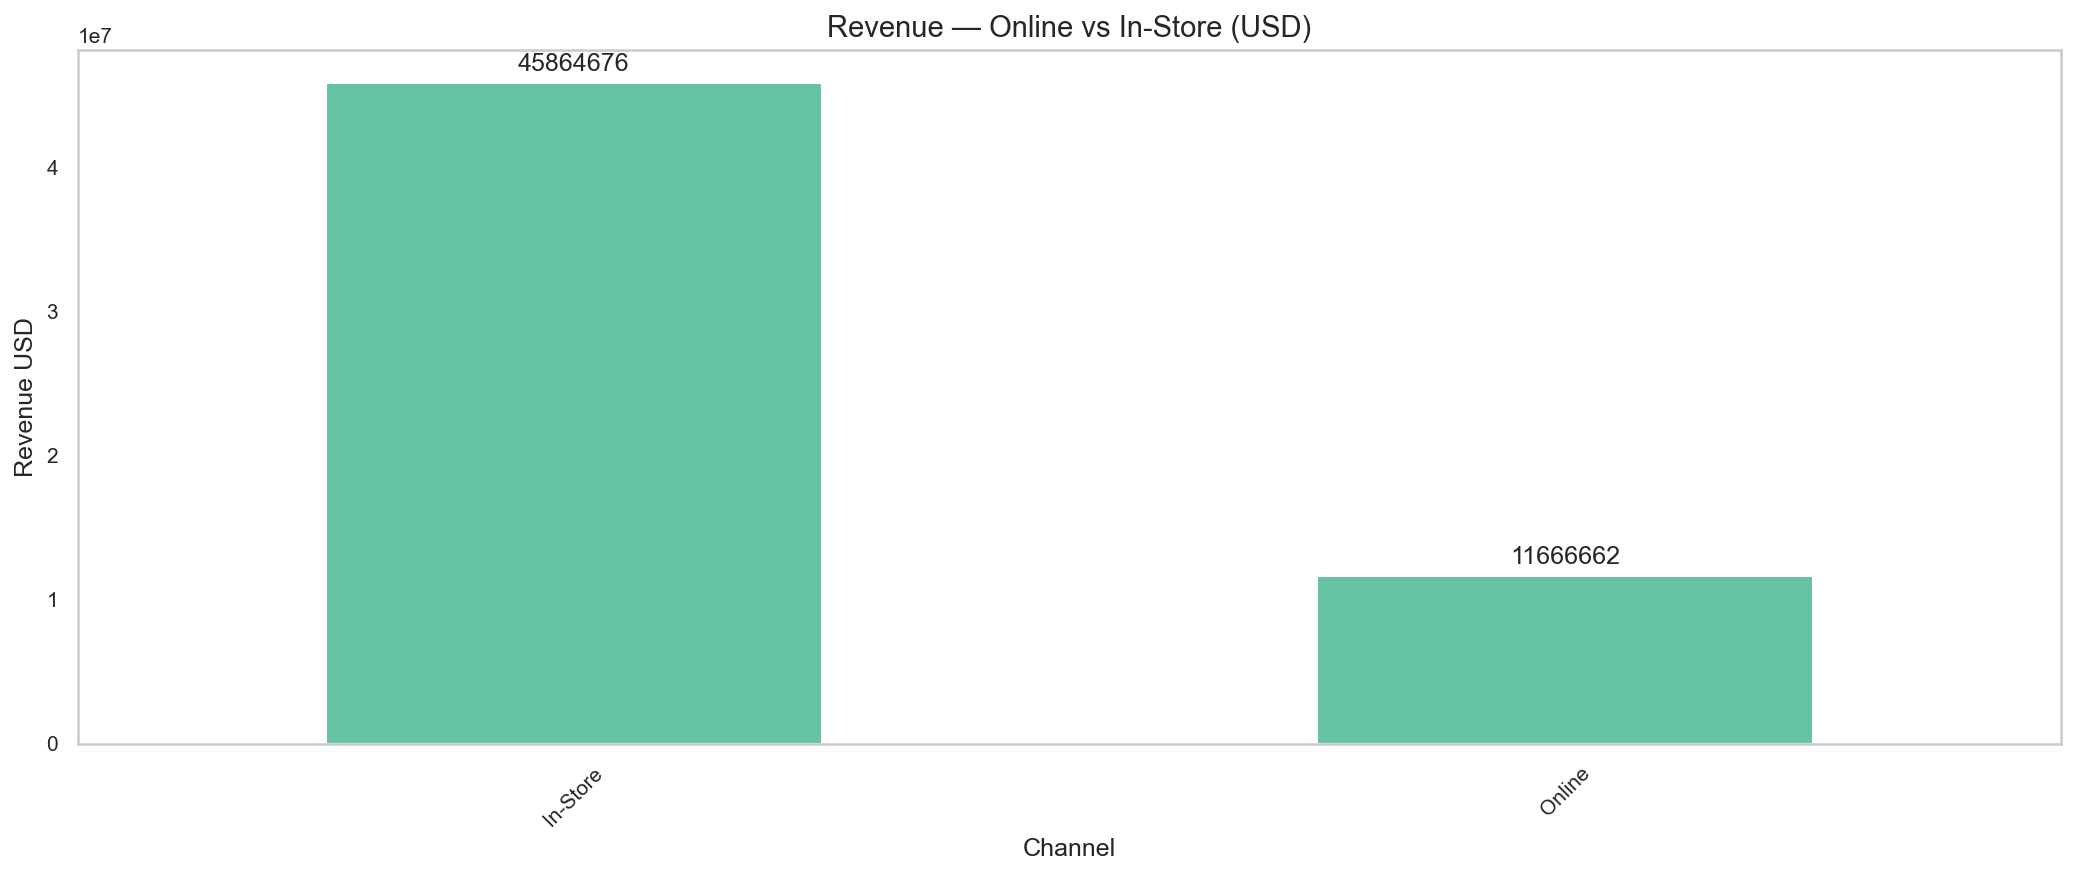

In [7]:
fig, ax = base.bar(
    channel.set_index("Channel")["Revenue USD"],
    title="Revenue — Online vs In-Store (USD)",
    xlabel="Channel",
    ylabel="Revenue USD",
    filename="sales_channel_revenue.png"
)

display(fig)

## Revenue by Country (Top 10)

Country
United States     29871631.17
United Kingdom     9224516.74
Germany            6146258.43
Canada             3592965.46
Italy              2803649.62
Netherlands        2227264.29
Australia          1945312.16
France             1719740.59
Name: Revenue USD, dtype: float64

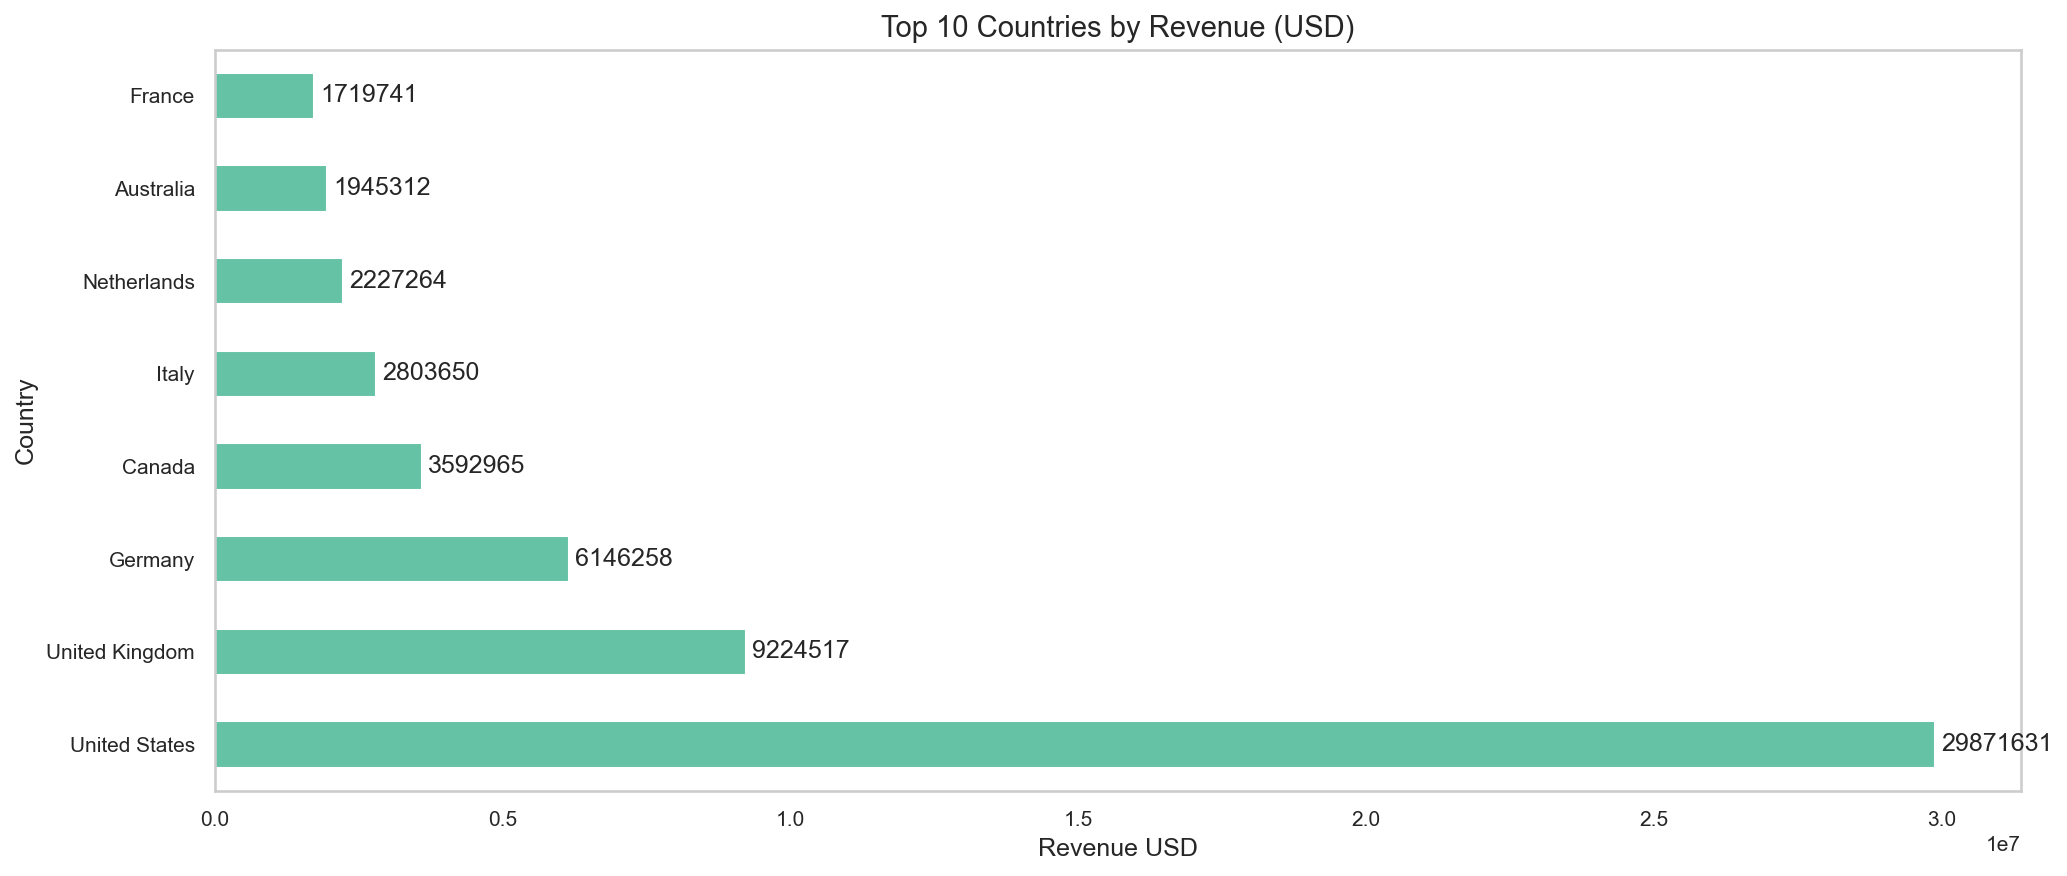

In [8]:
by_country = sales.revenue_by_country(df, n=10)
display(by_country)
fig, ax = base.horizontal_bar(
    by_country,
    title="Top 10 Countries by Revenue (USD)",
    xlabel="Revenue USD",
    ylabel="Country",
    filename="sales_revenue_by_country.png"
)

display(fig)

## Revenue by Category

,Category,Revenue USD
3,Computers,19926310.86
5,Home Appliances,11121941.72
1,Cameras and camcorders,6694412.72
2,Cell phones,6394703.50
7,TV and Video,6147587.83
0,Audio,3271311.85
6,"Music, Movies and Audio Books",3227529.10
4,Games and Toys,747540.88


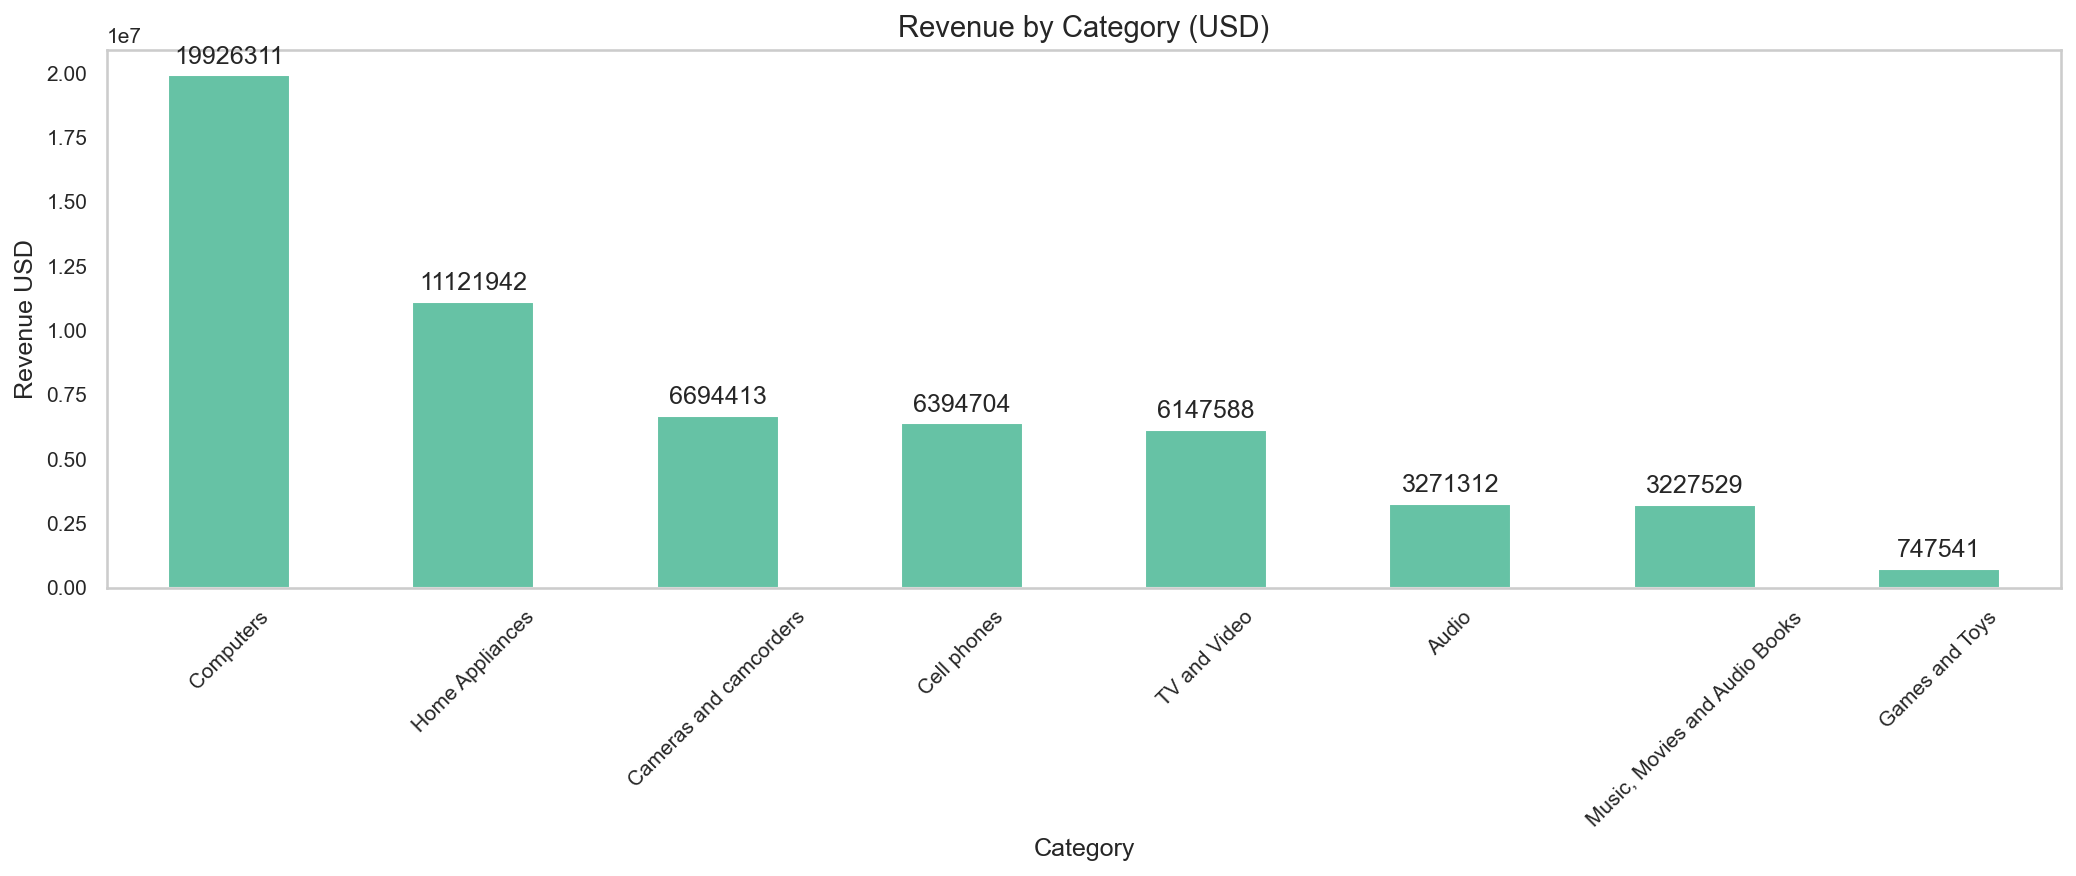

In [9]:
by_category = sales.revenue_by_category(df)
display(by_category)
fig, ax = base.bar(
    by_category.set_index("Category")["Revenue USD"],
    title="Revenue by Category (USD)",
    xlabel="Category",
    ylabel="Revenue USD",
    filename="sales_revenue_by_category.png"
)

display(fig)

## Top 10 Products by Revenue

Product Name
WWI Desktop PC2.33 X2330 Black                 520094.44
Adventure Works Desktop PC2.33 XD233 Silver    485803.32
Adventure Works Desktop PC2.33 XD233 Brown     481831.75
Adventure Works Desktop PC2.33 XD233 Black     463255.80
Adventure Works Desktop PC2.33 XD233 White     451062.10
WWI Desktop PC2.33 X2330 White                 441834.82
WWI Desktop PC2.33 X2330 Brown                 441679.61
Adventure Works 52" LCD HDTV X590 White        415358.64
Adventure Works 52" LCD HDTV X590 Silver       385305.22
Adventure Works 52" LCD HDTV X590 Black        382866.55
Name: Revenue USD, dtype: float64

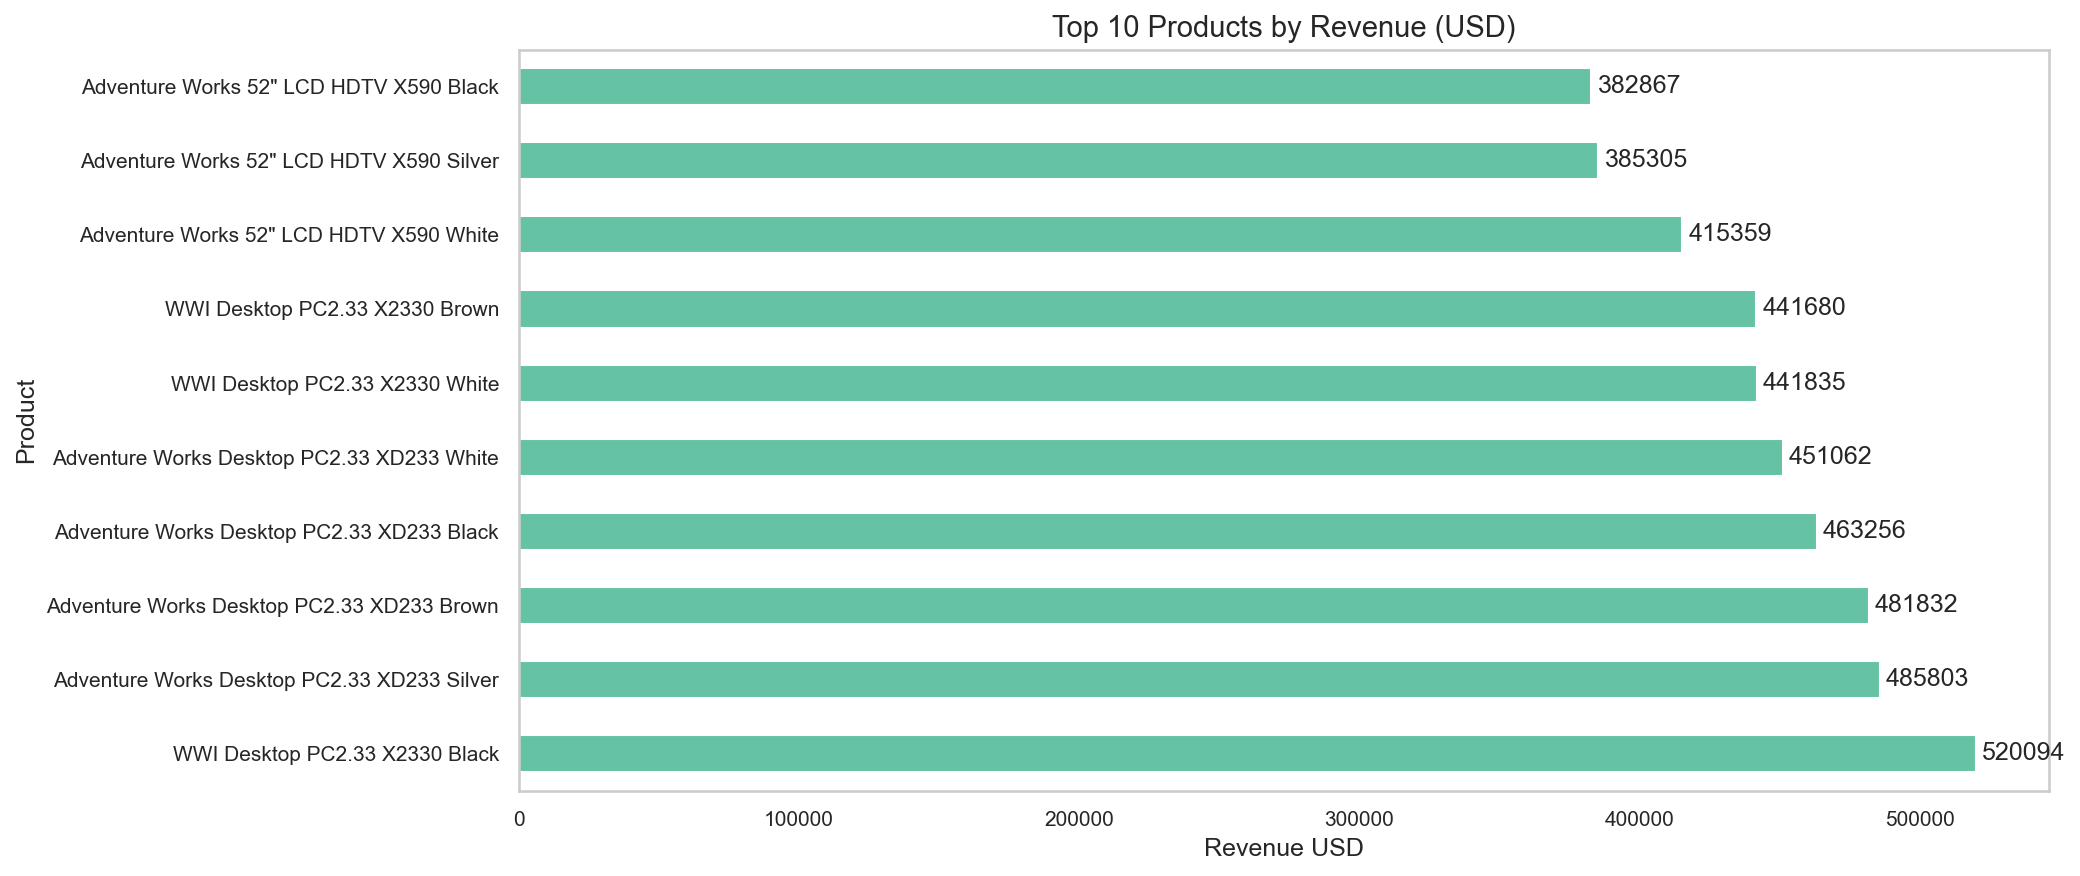

In [10]:
top_products = sales.top_products_by_revenue(df, n=10)
display(top_products)
fig, ax = base.horizontal_bar(
    top_products,
    title="Top 10 Products by Revenue (USD)",
    xlabel="Revenue USD",
    ylabel="Product",
    filename="sales_top_products.png"
)

display(fig)

## Delivery Days Distribution

count    13083.00
mean         4.53
std          2.12
min          1.00
25%          3.00
50%          4.00
75%          6.00
max         17.00
Name: Delivery Days, dtype: float64

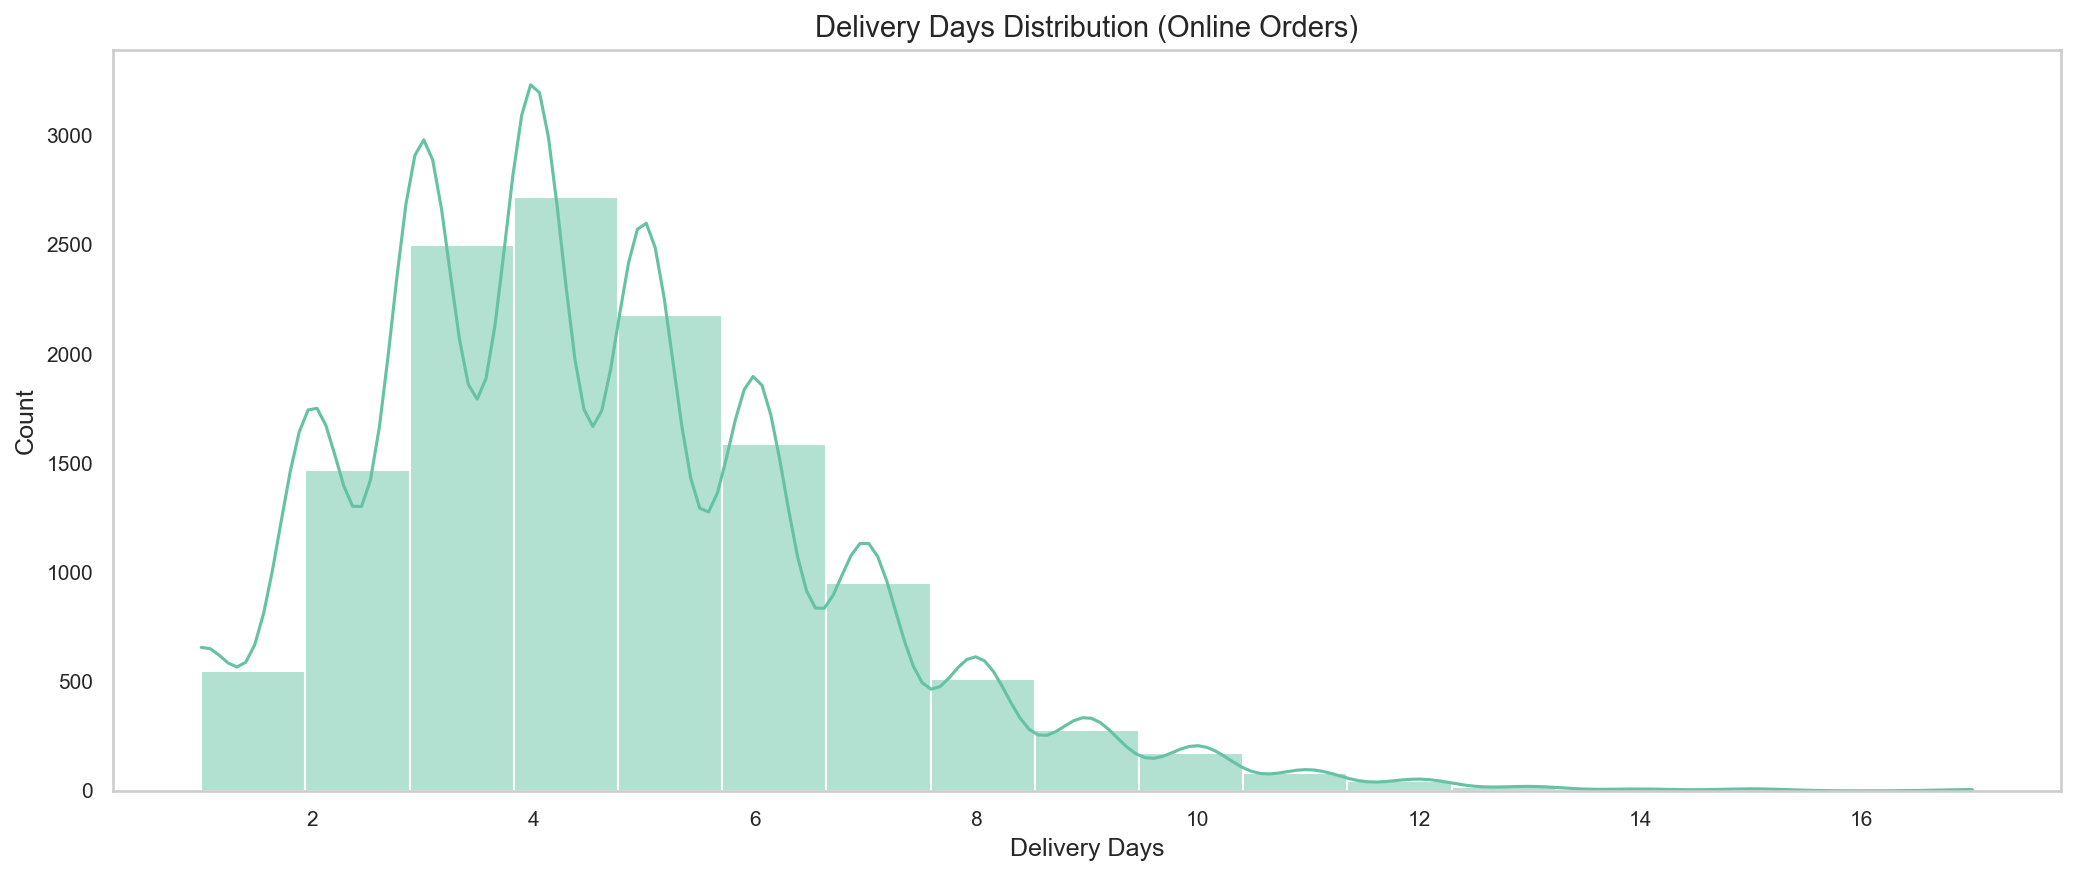

In [11]:
online_complete = df[
    (df["Is Online"] == True) & 
    (df["Is Delivery Pending"] == False)
]

display(sales.delivery_days_stats(online_complete))

fig, ax = base.histogram(
    online_complete["Delivery Days"].dropna(),
    title="Delivery Days Distribution (Online Orders)",
    xlabel="Delivery Days",
    ylabel="Count",
    bins=17,
    filename="sales_delivery_days.png"
)

display(fig)

## Sales Analysis — Findings

### Revenue Trend
- Revenue grew from $7.2M (2016) to a peak of $18.6M (2019) — 157% growth over 3 years.
- Sharp decline in 2020 ($9.5M, -49%) and 2021 ($1.1M, -89%).
- 2021 is partial — dataset ends February 2021, so $1.1M covers only ~7 weeks.
- Monthly chart shows recurring volatility — likely seasonal or campaign-driven patterns.

### Year over Year Growth
- 2018 was the strongest growth year at +73.45%.
- Growth decelerated to +39.28% in 2019 — still strong but slowing.
- 2020 dropped -49.06% — consistent with global disruption.
- 2021 shows -88.61% but is not comparable — partial year only.

### Online vs In-Store
- In-Store orders: 49,719 (79%) vs Online: 13,165 (21%).
- In-Store revenue: $45.9M (80%) vs Online: $11.7M (20%).
- The business is predominantly physical — 66 physical stores across multiple countries vs 1 online store.
- Average order value is similar across both channels.

### Delivery Performance (Online Orders Only)
- Physical store customers collect in store — no delivery applies.
- Online orders: 13,165 total, 13,083 completed, 82 pending at dataset cutoff.
- Mean delivery time: 4.53 days. Median: 4 days.
- 75% of online orders delivered within 6 days.
- Range: 1 to 17 days. No failed or negative delivery times.

### Revenue by Country
- United States generates $29.9M — more than all other countries combined.
- United Kingdom second at $9.2M, Germany third at $6.1M.
- Australia ($1.9M) and France ($1.7M) are weakest relative to their customer share.

### Revenue by Category
- Computers lead at $19.9M — nearly double Home Appliances ($11.1M).
- Cameras, Cell Phones, and TV and Video clustered between $6.1M and $6.7M.
- Games and Toys weakest at $747K.

### Top Products
- Desktop PCs dominate the top 10 — Adventure Works XD233 and WWI X2330 variants.
- Three Adventure Works 52" LCD HDTV variants also appear.
- High-ticket desktops and large-screen TVs drive individual product revenue.